# Toy Gospel Social Network Analysis

In [5]:
#!pip install kagglehub
import kagglehub

# Download latest version
path = kagglehub.dataset_download("bradystephenson/bibledata")

print("Path to dataset files:", path)

Path to dataset files: /home/erinbrzusek/.cache/kagglehub/datasets/bradystephenson/bibledata/versions/269


In [6]:
import os
import itertools
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt

# local directory
DATA_DIR = "/home/erinbrzusek/.cache/kagglehub/datasets/bradystephenson/bibledata/versions/268"

# load datasets
person_verse_path = os.path.join(DATA_DIR, "BibleData-PersonVerse.csv")
person_names_path = os.path.join(DATA_DIR, "BibleData-Person.csv")

df_pv = pd.read_csv(person_verse_path)
df_names = pd.read_csv(person_names_path)

df_pv.head()

,person_verse_id,reference_id,person_label_id,person_id,person_label,person_label_count,person_verse_sequence,person_verse_notes
0,GEN 1:1__YHVH_1_1,GEN 1:1,YHVH_1_1,YHVH_1,G-d,1.0,1,NaN
1,GEN 1:2__YHVH_1_1,GEN 1:2,YHVH_1_1,YHVH_1,G-d,1.0,2,NaN
2,GEN 1:3__YHVH_1_1,GEN 1:3,YHVH_1_1,YHVH_1,G-d,1.0,3,NaN
3,GEN 1:4__YHVH_1_1,GEN 1:4,YHVH_1_1,YHVH_1,G-d,1.0,4,NaN
4,GEN 1:5__YHVH_1_1,GEN 1:5,YHVH_1_1,YHVH_1,G-d,1.0,5,NaN


In [7]:
df_names.head()

,person_id,person_name,surname,unique_attribute,sex,tribe,person_notes,name_instance,person_sequence
0,YHVH_1,YHVH,NaN,"Holy, Holy, Holy (ISA 6:3) and too many others...",male,NaN,NaN,1,1
1,Adam_1,Adam,NaN,first man (1CO 15:45),male,NaN,NaN,1,2
2,Eve_1,Eve,NaN,"first woman, created from Adam (GEN 2:22)",female,NaN,NaN,1,3
3,Cain_1,Cain,NaN,"first son of Adam (GEN 4:1), cursed from the g...",male,NaN,NaN,1,4
4,Abel_1,Abel,NaN,"son of Adam(GEN 4:2), first person murdered (G...",male,NaN,NaN,1,5


Nodes: 78
Edges: 190

Top 5 Most Central Characters:
- YHVH: 0.338
- James: 0.182
- Simon: 0.143
- John: 0.130
- Jacob: 0.130

Network Assortativity Coefficient: -0.0654


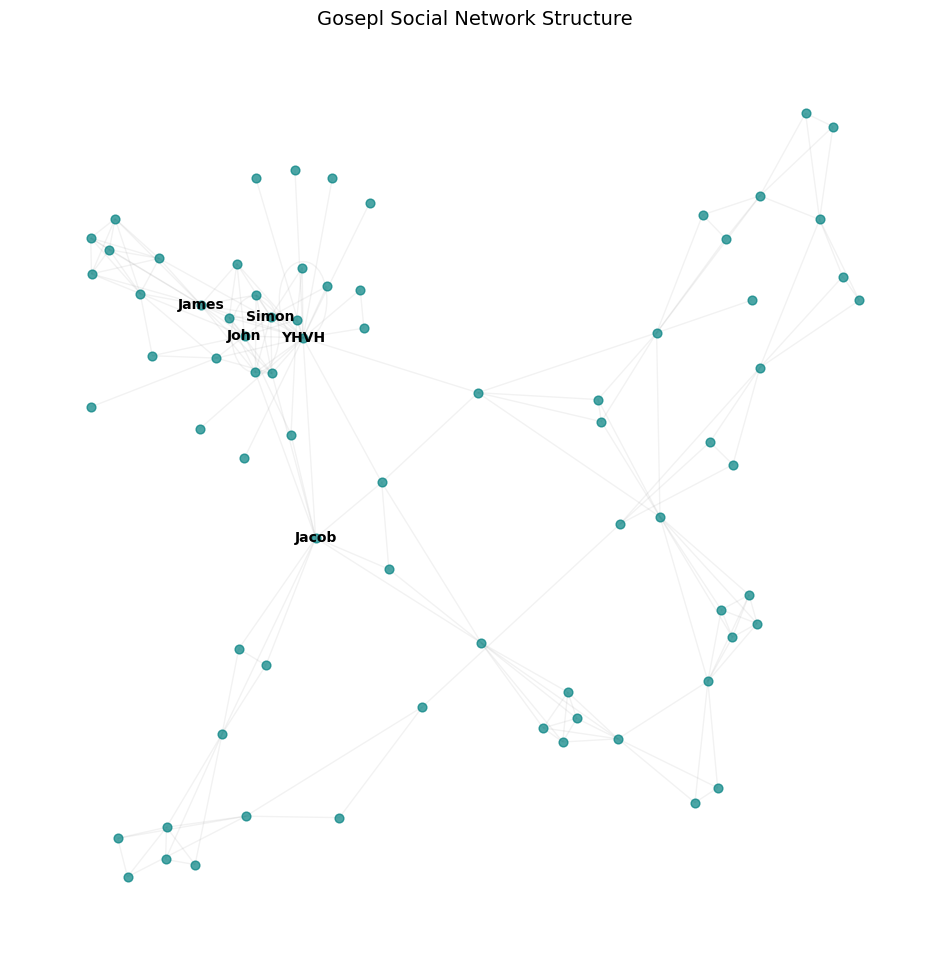

In [8]:
# match person id to names
name_map = dict(zip(df_names['person_id'], df_names['person_name']))
# filter for gospels
gospel_abbreviations = ['MAT'] #, 'MRK', 'LUK', 'JHN'
# split on book names
df_pv['book_abbr'] = df_pv['reference_id'].str.split(' ').str[0]
df_gospels = df_pv[df_pv['book_abbr'].isin(gospel_abbreviations)].copy()

verse_groups = df_gospels.groupby(['reference_id'])['person_id'].apply(list)

# initialize empty weighted graph
G = nx.Graph()

# edges using combinations w/in verse
for characters in verse_groups:
    if len(characters) > 1:
        # all unique pairs
        pairs = itertools.combinations(set(characters), 2)
        for p1, p2 in pairs:
            name1 = name_map.get(p1, p1)
            name2 = name_map.get(p2, p2)
            
            # edge calculations
            if G.has_edge(name1, name2):
                G[name1][name2]['weight'] += 1
            else:
                G.add_edge(name1, name2, weight=1)

# eda
print(f"Nodes: {G.number_of_nodes()}")
print(f"Edges: {G.number_of_edges()}")

# centrality
degree_cent = nx.degree_centrality(G)
top_nodes = sorted(degree_cent.items(), key=lambda x: x[1], reverse=True)[:5]
print("\nTop 5 Most Central Characters:")
for name, cent in top_nodes:
    print(f"- {name}: {cent:.3f}")

# assortativity
assortativity = nx.degree_assortativity_coefficient(G)
print(f"\nNetwork Assortativity Coefficient: {assortativity:.4f}")

plt.figure(figsize=(12, 12))
main_component = G.subgraph(max(nx.connected_components(G), key=len))

pos = nx.spring_layout(main_component, k=0.15, seed=42)
nx.draw_networkx_nodes(main_component, pos, node_size=40, node_color='teal', alpha=0.7)
nx.draw_networkx_edges(main_component, pos, alpha=0.1, edge_color='gray')

top_labels = {name: name for name, _ in top_nodes if name in main_component}
nx.draw_networkx_labels(main_component, pos, labels=top_labels, font_size=10, font_weight='bold')

plt.title("Gosepl Social Network Structure", fontsize=14)
plt.axis('off')
plt.show()

### Quran Toy Social Network

In [9]:
import itertools
import pandas as pd
import networkx as nx
import requests

# 1. Fetch the entire Quran (English Translation) via API
print("Fetching Quranic text from API...")
# Using the standard Sahih International translation (edition: en.sahih)
url = "https://api.alquran.cloud/v1/quran/en.sahih"
response = requests.get(url).json()

# Parse the JSON response into a flat list of verses
verses_data = []
for surah in response['data']['surahs']:
    surah_num = surah['number']
    surah_name = surah['englishName']
    for ayah in surah['ayahs']:
        verses_data.append({
            'reference_id': f"QURAN {surah_num}:{ayah['numberInSurah']}",
            'text': ayah['text']
        })

df_quran = pd.DataFrame(verses_data)
print(f"Loaded {len(df_quran)} verses across 114 Surahs.\n")

# 2. Define our target entities (Prophets/Angels/Key Named Figures)
# We include known aliases/variations in lists to catch different translations.
character_dictionary = {
    'Moses (Musa)': ['Moses', 'Musa'],
    'Abraham (Ibrahim)': ['Abraham', 'Ibrahim'],
    'Jesus (Isa)': ['Jesus', 'Isa', 'Messiah'],
    'Mary (Maryam)': ['Mary', 'Maryam'],
    'Noah (Nuh)': ['Noah', 'Nuh'],
    'Adam': ['Adam'],
    'Gabriel (Jibril)': ['Gabriel', 'Jibril'],
    'Satan (Iblis)': ['Satan', 'Iblis', 'Shaytan'],
    'Joseph (Yusuf)': ['Joseph', 'Yusuf'],
    'Lot (Lut)': ['Lot', 'Lut'],
    'Aaron (Harun)': ['Aaron', 'Harun'],
    'Pharaoh': ['Pharaoh', 'Firun'],
    'David (Dawud)': ['David', 'Dawud'],
    'Solomon (Sulaiman)': ['Solomon', 'Sulaiman']
}

# 3. Scan verses for co-occurring characters
G_quran = nx.Graph()

print("Building co-presence network matrix...")
for _, row in df_quran.iterrows():
    verse_text = row['text']
    present_characters = []
    
    # Check which entities show up in this specific verse
    for normalized_name, aliases in character_dictionary.items():
        if any(alias in verse_text for alias in aliases):
            present_characters.append(normalized_name)
            
    # If more than one character is mentioned in the same Ayah, create weighted edges
    if len(present_characters) > 1:
        pairs = itertools.combinations(set(present_characters), 2)
        for p1, p2 in pairs:
            if G_quran.has_edge(p1, p2):
                G_quran[p1][p2]['weight'] += 1
            else:
                G_quran.add_edge(p1, p2, weight=1)

# 4. Extract Structural Topography
print("\n--- Quranic Toy Network Topology ---")
print(f"Total Unique Characters (Nodes): {G_quran.number_of_nodes()}")
print(f"Total Relationship Connections (Edges): {G_quran.number_of_edges()}")

# Calculate Degree Centrality
degree_cent = nx.degree_centrality(G_quran)
sorted_centrality = sorted(degree_cent.items(), key=lambda x: x[1], reverse=True)

print("\nTop Character Centrality Distributions:")
for name, score in sorted_centrality[:5]:
    print(f"- {name}: {score:.3f}")

# Look at strong narrative clustering/cliques
print("\nStrongest Weighted Links (Frequent Shared Verses):")
edge_weights = [(u, v, d['weight']) for u, v, d in G_quran.edges(data=True)]
for u, v, w in sorted(edge_weights, key=lambda x: x[2], reverse=True)[:5]:
    print(f"- {u} <---> {v} (Shared Verses: {w})")

Fetching Quranic text from API...
Loaded 6236 verses across 114 Surahs.

Building co-presence network matrix...

--- Quranic Toy Network Topology ---
Total Unique Characters (Nodes): 13
Total Relationship Connections (Edges): 46

Top Character Centrality Distributions:
- Noah (Nuh): 0.917
- Moses (Musa): 0.833
- Abraham (Ibrahim): 0.833
- Jesus (Isa): 0.750
- Aaron (Harun): 0.667

Strongest Weighted Links (Frequent Shared Verses):
- Moses (Musa) <---> Pharaoh (Shared Verses: 21)
- Jesus (Isa) <---> Mary (Maryam) (Shared Verses: 19)
- Moses (Musa) <---> Aaron (Harun) (Shared Verses: 15)
- Jesus (Isa) <---> Abraham (Ibrahim) (Shared Verses: 11)
- Abraham (Ibrahim) <---> Noah (Nuh) (Shared Verses: 8)


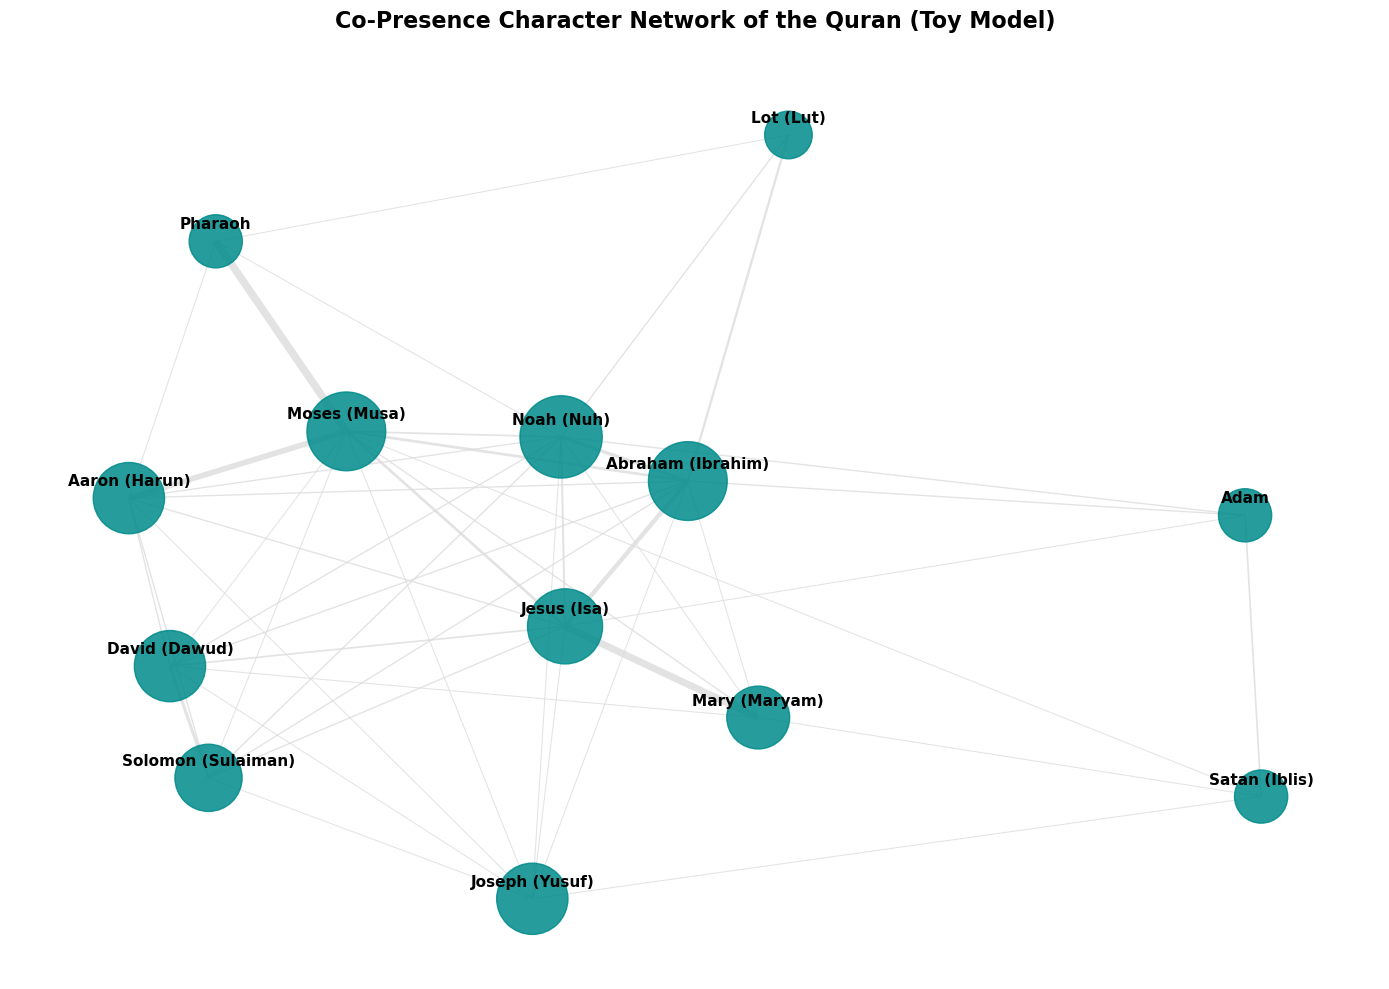

In [10]:
import matplotlib.pyplot as plt

# 1. Set up canvas dimensions
plt.figure(figsize=(14, 10))

# 2. Compute a layout configuration using a force-directed layout
# k control the optimal distance between nodes (higher = more spread out)
pos = nx.spring_layout(G_quran, k=0.45, seed=42)

# 3. Scale node sizes dynamically based on their connection count
node_sizes = [degree_cent[node] * 3500 + 300 for node in G_quran.nodes()]

# 4. Extract edge weights to scale line thicknesses
weights = [G_quran[u][v]['weight'] for u, v in G_quran.edges()]
# Normalize weights so lines don't get ridiculously thick
max_weight = max(weights) if weights else 1
edge_widths = [(w / max_weight) * 5 + 0.5 for w in weights]

# 5. Draw network elements
nx.draw_networkx_nodes(
    G_quran, 
    pos, 
    node_size=node_sizes, 
    node_color="darkcyan", 
    alpha=0.85
)

nx.draw_networkx_edges(
    G_quran, 
    pos, 
    width=edge_widths, 
    edge_color="gainsboro", 
    alpha=0.8
)

# 6. Apply text labels with a slight vertical offset so they sit neatly
label_pos = {k: [v[0], v[1] + 0.04] for k, v in pos.items()}
nx.draw_networkx_labels(
    G_quran, 
    label_pos, 
    font_size=11, 
    font_weight="bold", 
    font_color="black"
)

# 7. Final plot adjustments
plt.title("Co-Presence Character Network of the Quran (Toy Model)", fontsize=16, fontweight='bold', pad=20)
plt.axis("off")  # Hides coordinate axes
plt.tight_layout()
plt.show()